In [17]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = ''

# Load Dataset

In [ ]:
playlists_df = pd.read_parquet(os.path.join(BASE_DIR, 'playlist_diversity.parquet'))
print(f'Dataset loaded with shape: {playlists_df.shape}')

Dataset loaded with shape: (18504, 7)


# Identifying Feature Columns for Clustering

**Identifying Feature Columns for Clustering:**
   - Selects all columns with data type `float64` (assumed to be numerical features) and converts them into a list.
   - These columns will be used as features for clustering.


In [19]:
# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Identify feature columns for clustering
feature_columns = playlists_df.select_dtypes(include=['float64']).columns.tolist()
print(f'Features for clustering: {feature_columns}')

Features for clustering: ['era_diversity', 'length_diversity', 'artist_diversity', 'popularity_diversity', 'sentiment_diversity', 'genre_diversity']


# Correlation Heatmap Analysis
**Correlation Matrix Calculation:**

- Computes the pairwise correlation for all numerical features in feature_columns. Each cell in this matrix represents the correlation coefficient between two features, with values ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation).

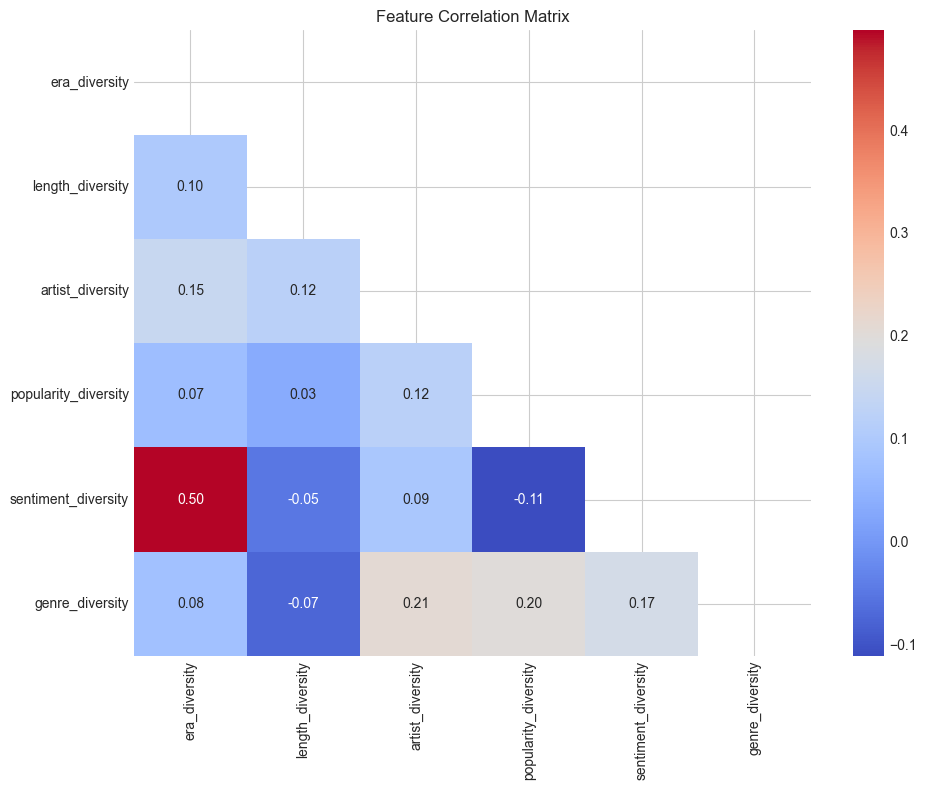

In [20]:
# Correlation heatmap to see relationships between features
plt.figure(figsize=(10, 8))
correlation_matrix = playlists_df[feature_columns].corr()
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observations from Heatmap:**
- `era_diversity` and `sentiment_diversity` have the highest positive correlation (0.5). This suggests that playlists spanning multiple eras also exhibit a wider range of sentiments.
- However, it is not high enough to warrant multicollinearity issues. 

In general, all correlations are relatively modest, meaning no 2 features are highly redundant. This is GOOD for clustering as it suggests that each feature can provide unique information about the playlists.

# PCA Projection of Playlist Features (3 PCs)
**Feature Scaling:**
- Create a copy of the original DataFrame features `X = playlists_df[feature_columns].copy()` and apply StandardScaler to standardize each feature to have mean 0 and standard deviation 1. 
- This step is crucial for many machine learning algorithms (including PCA) to avoid biases caused by differences in feature scales.

**PCA Dimensionality Reduction:**
- Instantiate a PCA object with n_components=3, meaning we want to project the data onto 3 principal components.

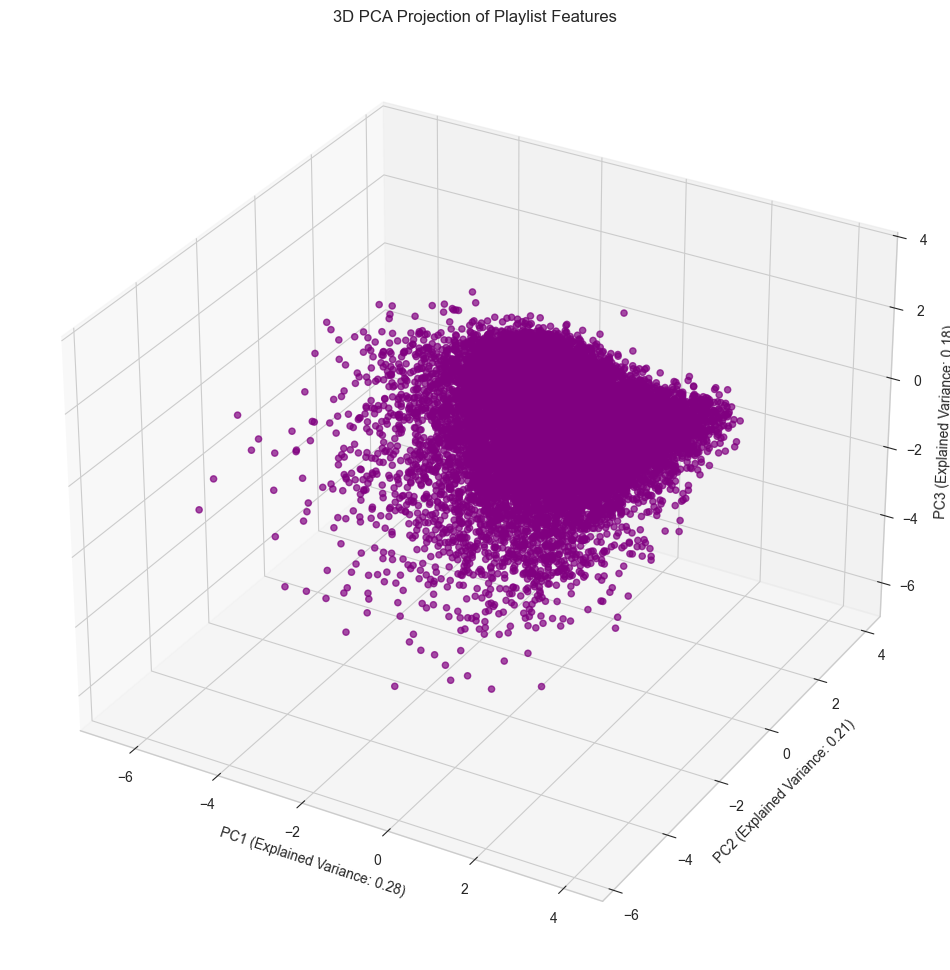

In [21]:
# Scale the features
X = playlists_df[feature_columns].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

# Apply PCA for dimensionality reduction (3 components)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])

# 3D Plot of the PCA results
fig = plt.figure(figsize=(12, 20))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    pca_df['PC3'], 
    alpha=0.7, 
    c='purple'
)

ax.set_title('3D PCA Projection of Playlist Features')
ax.set_xlabel(f'PC1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2f})')
ax.set_ylabel(f'PC2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2f})')
ax.set_zlabel(f'PC3 (Explained Variance: {pca.explained_variance_ratio_[2]:.2f})')

plt.show()


**Observations from Scatter plot:**
- Explained variance:
    - PC1: Explains ~28% of the variance
    - PC2: Explains ~21% of the variance
    - PC3: Explains ~18% of the variance
    - In total, the 3 PCs account for about 67% of the variance

- Distribution of points:
    - Most data points appear densely packed in the central region, meaning many playlists share relatively similar feature values after clustering.

# Finding Optimal Number of Clusters
**Inertia Calculation (Elbow Method):**
- A list called `inertias` is populated by fitting K-Means with different numbers of clusters (k) and storing each model’s inertia_ (sum of squared distances from each point to its assigned cluster center).

**Plotting Inertia vs. Number of Clusters:**
- The elbow plot helps identify a point where the rate of decrease in inertia slows down significantly—this is often considered an optimal number of clusters.

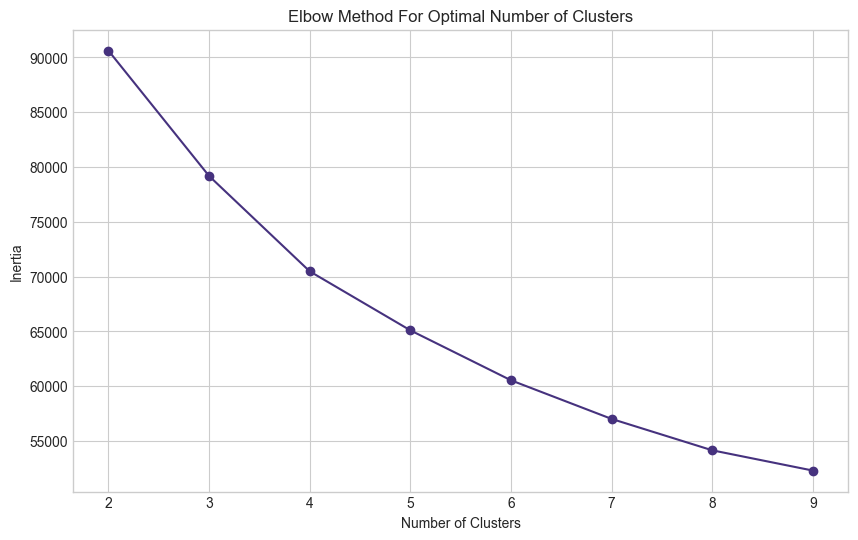

In [22]:
# Find optimal number of clusters using the elbow method
inertias = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow method curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

**Automatic Detection with kneed:**
- Using the KneeLocator, we set curve="convex" and direction="decreasing" to detect the “elbow” automatically.
- The kl.elbow attribute provides the estimated optimal number of clusters (best_k).
- In this case, it can also be visually observed that the optimal number of playlist segments (clusters) is 4.

**Applying K-Means Clustering:**
- A new K-Means model is created with n_clusters=best_k.
- Cluster labels are assigned to each playlist, and these labels are stored in playlists_df['cluster'].

**Cluster Centers (Original Scale):**
- The cluster centers are transformed back to the original feature scale using the inverse of the standardization transformation (scaler.inverse_transform).
- This provides a more intuitive view of what each cluster represents in terms of the original feature values.

In [23]:
from kneed import KneeLocator

# Assuming 'inertias' and 'k_range' were computed previously using the elbow method:
# inertias = [ ... ] computed for each k in k_range

# Automatically detect the elbow point
kl = KneeLocator(k_range, inertias, curve="convex", direction="decreasing")
best_k = kl.elbow
print(f'Best k based on the elbow method: {best_k}')

# Apply K-means with the optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
playlists_df['cluster'] = kmeans.fit_predict(X_scaled)

# Get cluster centers and transform back to original scale
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                               columns=feature_columns)
print('\nCluster Centers (Original Scale):')
print(cluster_centers)

Best k based on the elbow method: 4

Cluster Centers (Original Scale):
   era_diversity  length_diversity  artist_diversity  popularity_diversity  \
0       0.507801          0.945146          3.995380            428.321492   
1       0.488527          1.225294          5.530035            663.993656   
2       0.233404          1.399244          4.659840            533.525331   
3       1.363042          1.367701          5.300746            566.267415   

   sentiment_diversity  genre_diversity  
0             0.071105         0.362336  
1             0.063458         0.407327  
2             0.049587         0.330897  
3             0.083774         0.381747  


# 3D Visualization of K-means Clustering on PCA-Reduced Data
1. **Assign Cluster Labels to PCA Data:**  
   - Adds the cluster labels (obtained from K-means) to the PCA DataFrame, so that each point can be colored based on its cluster.

2. **Set Up a 3D Plot:**  
   - Creates a 3D figure with an increased figure size for better visibility.

3. **Plot the Data Points:**  
   - Uses a 3D scatter plot to display the playlists based on the first three principal components (PC1, PC2, PC3).
   - Colors each point using the 'viridis' colormap according to its cluster assignment.

4. **Overlay Cluster Centers:**  
   - Transforms the cluster centers into the PCA space and overlays them on the scatter plot using a distinct red “X” marker for easy identification.

5. **Display Cluster Distribution:**  
   - Prints the count of playlists in each cluster to provide an overview of the clustering outcome.

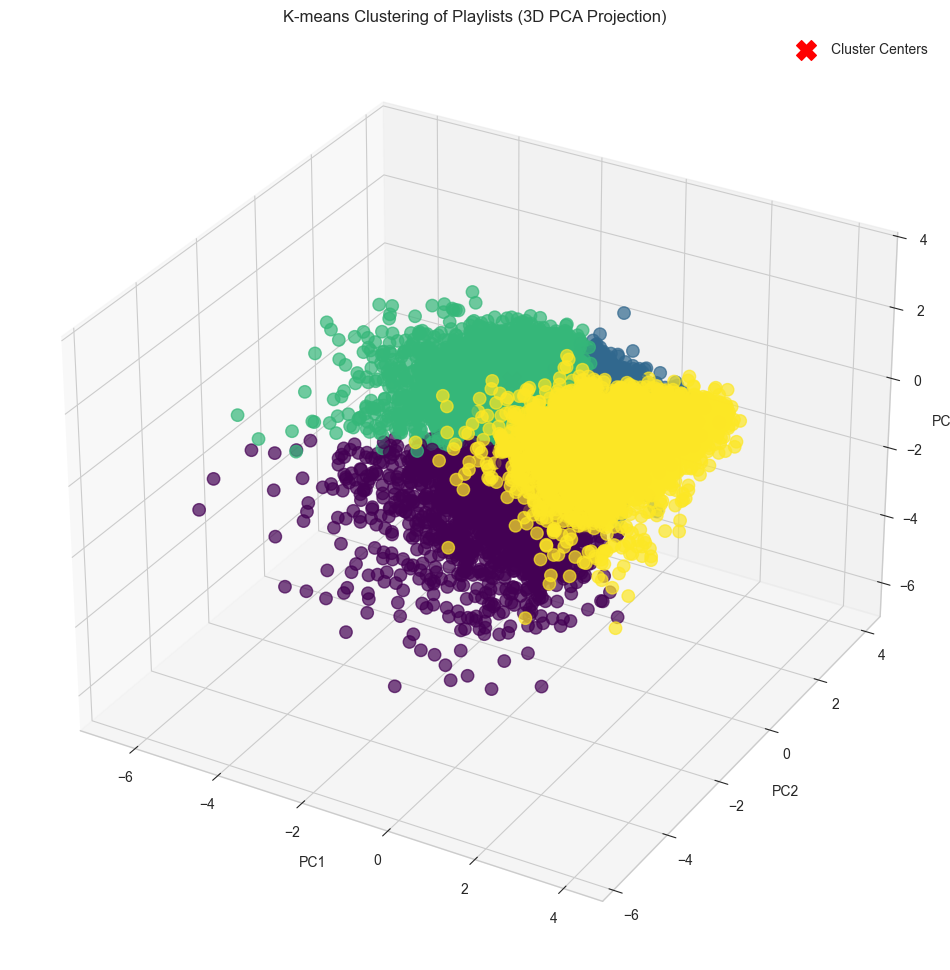


Cluster distribution:
cluster
0    2554
1    6141
2    5174
3    4635
Name: count, dtype: int64


In [24]:
# Visualize clusters in 3D PCA space
pca_df['cluster'] = playlists_df['cluster']

fig = plt.figure(figsize=(12, 20))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the data points in 3D
scatter = ax.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    pca_df['PC3'],
    c=pca_df['cluster'],   # color by cluster label
    cmap='viridis',        # use the viridis colormap
    s=80,
    alpha=0.7
)

ax.set_title('K-means Clustering of Playlists (3D PCA Projection)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Plot cluster centers in the same 3D PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    centers_pca[:, 2],
    s=200,
    marker='X',
    c='red',
    label='Cluster Centers'
)

# Optional: add a legend or a colorbar
ax.legend()
plt.show()

# Count of playlists in each cluster
cluster_counts = playlists_df['cluster'].value_counts().sort_index()
print(f'\nCluster distribution:\n{cluster_counts}')


# Plotting Cluster Distribution

This code block visualizes the distribution of playlists across clusters using a bar chart. It performs the following steps:

1. **Bar Plot:**  
   - `cluster_counts.plot(kind='bar', color=sns.color_palette('viridis', n_colors=len(cluster_counts)))` plots the cluster counts as a bar chart.  
     - The `kind='bar'` parameter specifies that a bar chart should be used.
     - The `color` parameter assigns a color from the 'viridis' palette to each bar, ensuring that the number of colors matches the number of clusters.

2. **Titles and Labels:**  
   - `plt.title('Number of Playlists in Each Cluster')` sets the plot title.
   - `plt.xlabel('Cluster')` labels the x-axis.
   - `plt.ylabel('Count')` labels the y-axis.

3. **Axis Customization:**  
   - `plt.xticks(rotation=0)` ensures that the x-axis labels (cluster numbers) are displayed horizontally for better readability.
   - `plt.grid(axis='y')` adds grid lines along the y-axis to facilitate visual comparison of the counts.

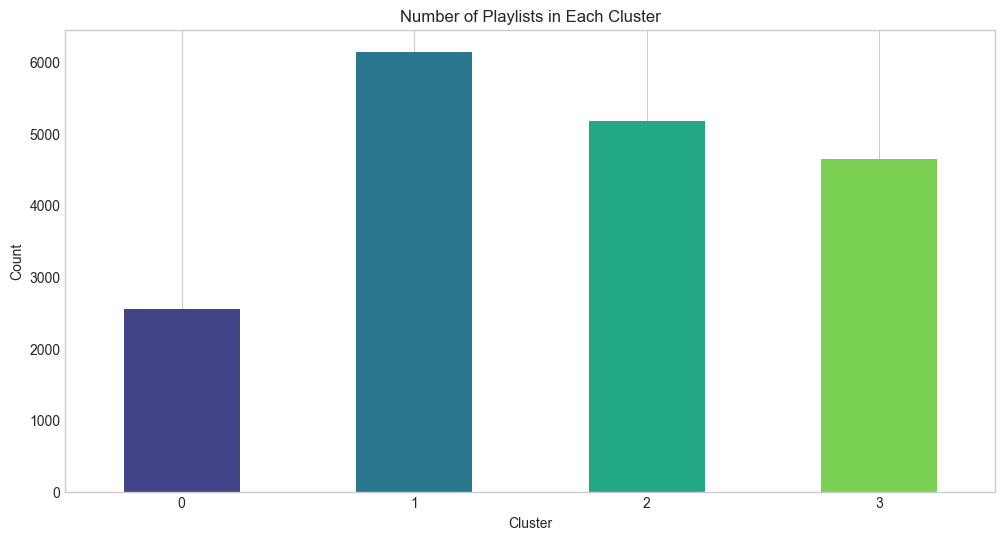

In [25]:
# Plot cluster distribution
plt.figure(figsize=(12, 6))
cluster_counts.plot(kind='bar', color=sns.color_palette('viridis', n_colors=len(cluster_counts)))
plt.title('Number of Playlists in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# Analyzing Feature Means by Cluster
1. Calculating Feature Means by Cluster
- Groups the DataFrame by the cluster column and computes the mean of all specified feature columns (feature_columns) for each cluster.
- This reveals how each cluster compares across the numerical features in terms of their average values.

2. Printing the Cluster Profiles
- print(cluster_profiles) displays the resulting DataFrame in the console, showing the average feature values per cluster.




Cluster Profiles (Feature Means):
         era_diversity  length_diversity  artist_diversity  \
cluster                                                      
0             0.507998          0.944927          3.994533   
1             0.489350          1.225154          5.531085   
2             0.233271          1.399171          4.660042   
3             1.363085          1.367865          5.299862   

         popularity_diversity  sentiment_diversity  genre_diversity  
cluster                                                              
0                  428.394994             0.071103         0.362280  
1                  663.906829             0.063480         0.407316  
2                  533.626639             0.049583         0.330986  
3                  566.211724             0.083789         0.381749  


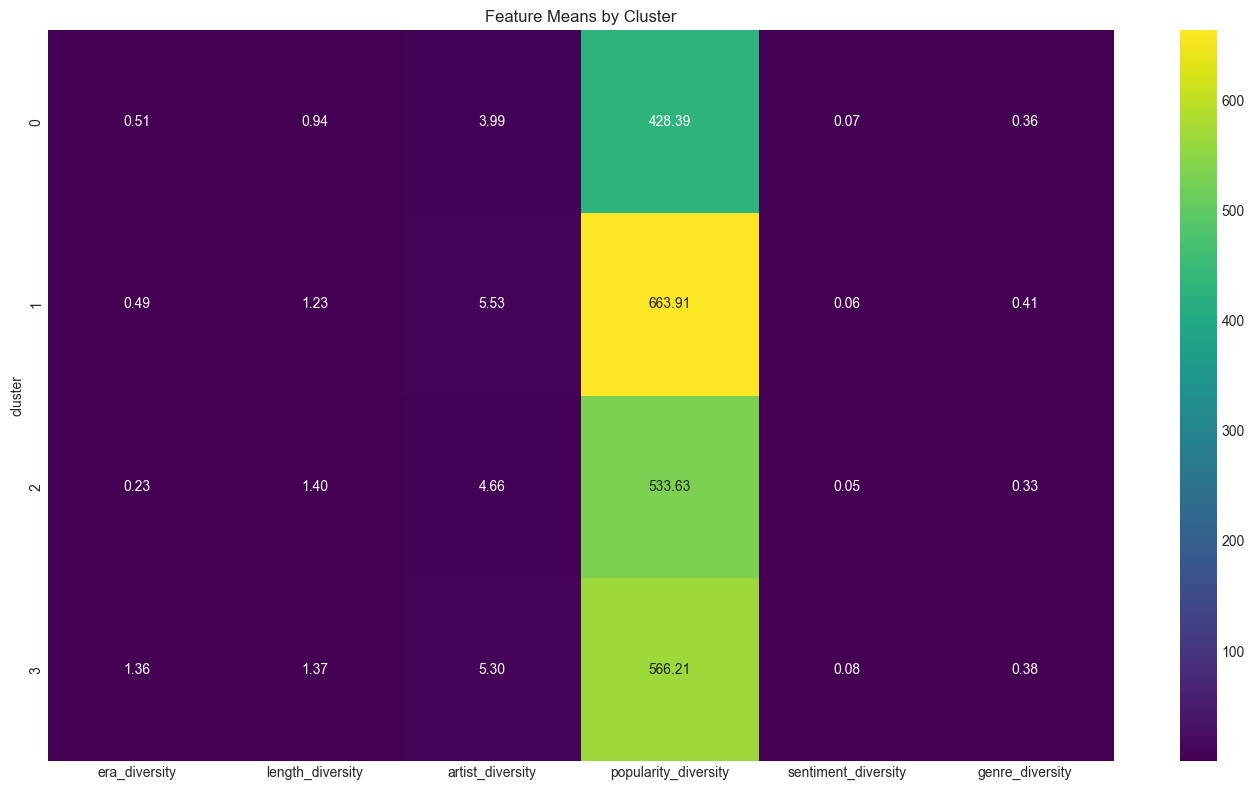

In [26]:
# Get the mean values for each feature by cluster
cluster_profiles = playlists_df.groupby('cluster')[feature_columns].mean()
print('\nCluster Profiles (Feature Means):')
print(cluster_profiles)

# Create a heatmap to visualize the differences between clusters
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles, annot=True, cmap='viridis', fmt='.2f')
plt.title('Feature Means by Cluster')
plt.tight_layout()
plt.show()

The heatmap above is not that meaningful in telling us the diversity due to the overwhelming popularity_diversity. Therefore, in the next section, we will interpret the results **after standardising the values**.

# Standardizing Feature Means by Cluster
- For each feature, we subtract the mean (across all clusters) and then divide by the standard deviation.
- This produces a z-score for each cluster’s feature mean, indicating how many standard deviations above or below the overall average that cluster is for that particular feature.


Standardized Feature Means by Cluster (Relative Importance):
         era_diversity  length_diversity  artist_diversity  \
cluster                                                      
0            -0.285045         -1.396233         -1.269004   
1            -0.322898         -0.044033          0.954747   
2            -0.842696          0.795664         -0.305856   
3             1.450638          0.644603          0.620113   

         popularity_diversity  sentiment_diversity  genre_diversity  
cluster                                                              
0                   -1.232290             0.287479        -0.257841  
1                    1.193477            -0.245211         1.140730  
2                   -0.148406            -1.216193        -1.229641  
3                    0.187219             1.173925         0.346751  


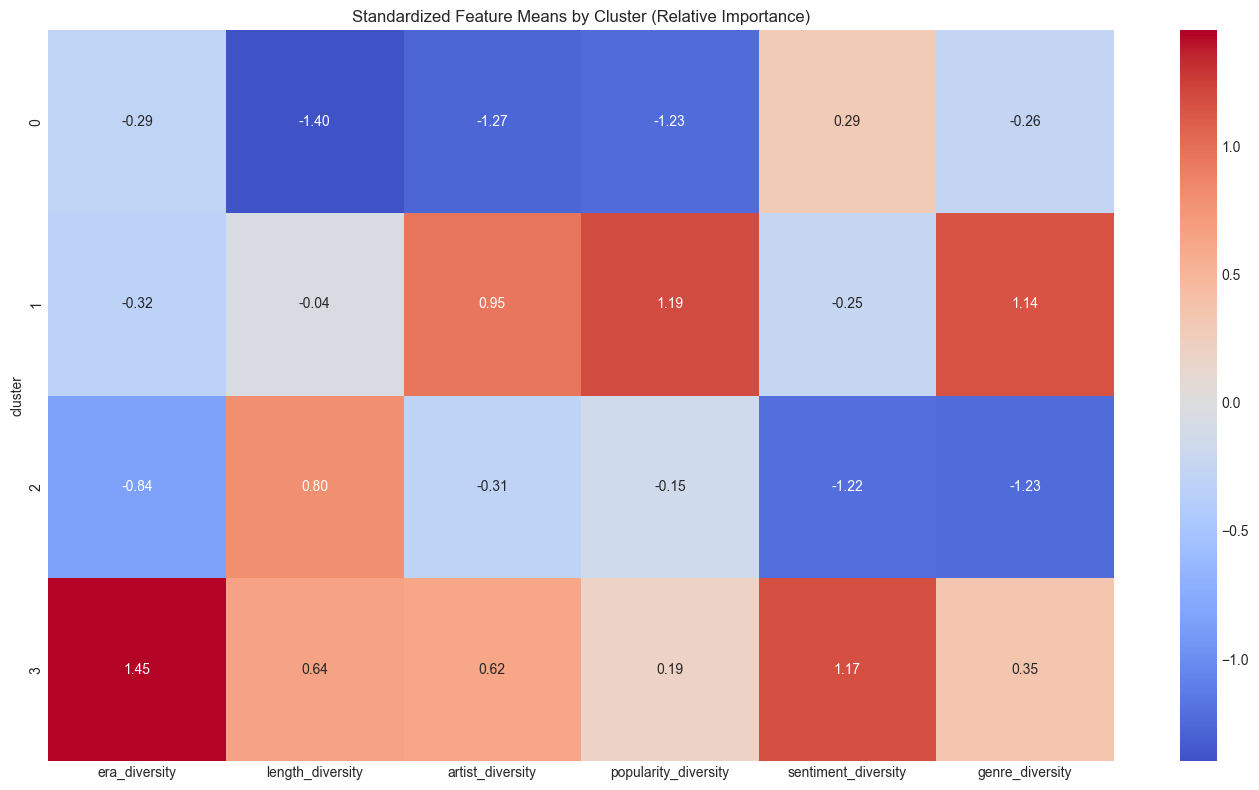

In [27]:
# Standardize the feature means for better comparison
cluster_profiles_scaled = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()
print('\nStandardized Feature Means by Cluster (Relative Importance):')
print(cluster_profiles_scaled)

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles_scaled, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Standardized Feature Means by Cluster (Relative Importance)')
plt.tight_layout()
plt.show()

# Cluster Segment Interpretations (Standardized Feature Means)

### **Cluster 0: "Consistent Loyalists"**
- **Justification:**
  - **Strongly negative across most features** (length, artist, popularity, sentiment): indicates low diversity in general.
  - Slightly above average in **sentiment diversity** only (+0.29), which isn’t strongly influential.
- **Summary:**  
  These users have relatively uniform playlists—likely made up of similar artists, song types, and emotional tones. They're not very exploratory and prefer familiar, consistent music.

---

### **Cluster 1: "Trend-Saavy Seekers"**
- **Justification:**
  - High **artist diversity (+0.95)** and **popularity diversity (+1.19)**: suggests they listen to a wide range of artists across various popularity levels.
  - Very high **genre diversity (+1.14)**: strongly genre-diverse listeners.
  - All other features hover around the average.
- **Summary:**  
  These users explore widely across both popular and obscure tracks, artists, and genres. They're trendy and curious, enjoying playlists that span musical styles and voices.

---

### **Cluster 2: "Focused Mood Crafters"**
- **Justification:**
  - Strong **negative sentiment diversity (-1.22)** and **genre diversity (-1.23)**: highly consistent in mood and genre.
  - Slightly above average in **length diversity (+0.80)**: varied track lengths, not very meaningful due to low magnitude.
  - Otherwise slightly below or near-neutral.
- **Summary:**  
  These users craft focused, consistent playlists—likely centered on a particular genre and mood. They're mood-oriented listeners who value emotional or stylistic cohesion.

---

### **Cluster 3: "Universal Explorer"**
- **Justification:**
  - **Strongest era diversity (+1.45)**: listens to music across multiple decades.
  - **High sentiment (+1.17)**, length (+0.64), artist (+0.62), and moderate genre diversity (+0.35)**: playlists are rich in emotional range and stylistic variety.
  - Near-average popularity diversity (+0.19): open to popular and niche music alike.
- **Summary:**  
  These users seek diverse musical experiences. They enjoy mixing eras, moods, and artists, crafting emotionally varied and eclectic playlists.

---

## Updated Cluster Labels (Standardized View)

| Cluster | Suggested Name           | Key Traits                                                                 |
|---------|---------------------------|----------------------------------------------------------------------------|
| 0       | Consistent Loyalists      | Low diversity across the board — consistent, familiar music                |
| 1       | Trend-Savvy Seekers       | High artist, genre, and popularity diversity — explores trends actively    |
| 2       | Focused Mood Crafters     | Low sentiment/genre diversity — builds consistent, vibe-specific playlists|
| 3       | Universal Explorer        | High era/sentiment/artist diversity — emotionally and historically diverse |

# Identifying Distinctive Features for Each Cluster
- Below is the code used to determine which features stand out the most (both positively and negatively) for each cluster. It relies on the **standardized** cluster profiles (`cluster_profiles_scaled`) to find the features with the highest and lowest z-scores in each cluster.

In [28]:
# Identify the most distinctive features for each cluster
distinctive_features = pd.DataFrame(index=cluster_profiles.index, columns=['Top Features', 'Bottom Features'])
for cluster in cluster_profiles_scaled.index:
    sorted_features = cluster_profiles_scaled.loc[cluster].sort_values(ascending=False)
    distinctive_features.at[cluster, 'Top Features'] = ', '.join(sorted_features.head(3).index)
    distinctive_features.at[cluster, 'Bottom Features'] = ', '.join(sorted_features.tail(3).index)

print('\nDistinctive Features by Cluster:')
print(distinctive_features)


Distinctive Features by Cluster:
                                              Top Features  \
cluster                                                      
0        sentiment_diversity, genre_diversity, era_dive...   
1        popularity_diversity, genre_diversity, artist_...   
2        length_diversity, popularity_diversity, artist...   
3        era_diversity, sentiment_diversity, length_div...   

                                           Bottom Features  
cluster                                                     
0        popularity_diversity, artist_diversity, length...  
1        length_diversity, sentiment_diversity, era_div...  
2        era_diversity, sentiment_diversity, genre_dive...  
3        artist_diversity, genre_diversity, popularity_...  


**Interpretation of results:**
### Top Features

Reflect the strongest positive deviations in standardized scores. For example, **Cluster 0** is highest in `sentiment_diversity`, `genre_diversity`, and `era_diversity`, suggesting these attributes are notably higher than the average across all clusters.

### Bottom Features

Indicate where the cluster has notably lower standardized scores. For instance, **Cluster 1** shows lower-than-average `length_diversity`, `sentiment_diversity`, and `era_diversity` relative to other clusters.

---

The above provides a quick reference for understanding each cluster’s standout characteristics (top features) and potential weaknesses or lesser-used attributes (bottom features). It helps in naming or describing clusters more intuitively (e.g., a cluster with high artist diversity could be labeled as “Artist Explorers,” whereas one with low era diversity might be considered “Era-Specific Enthusiasts”).


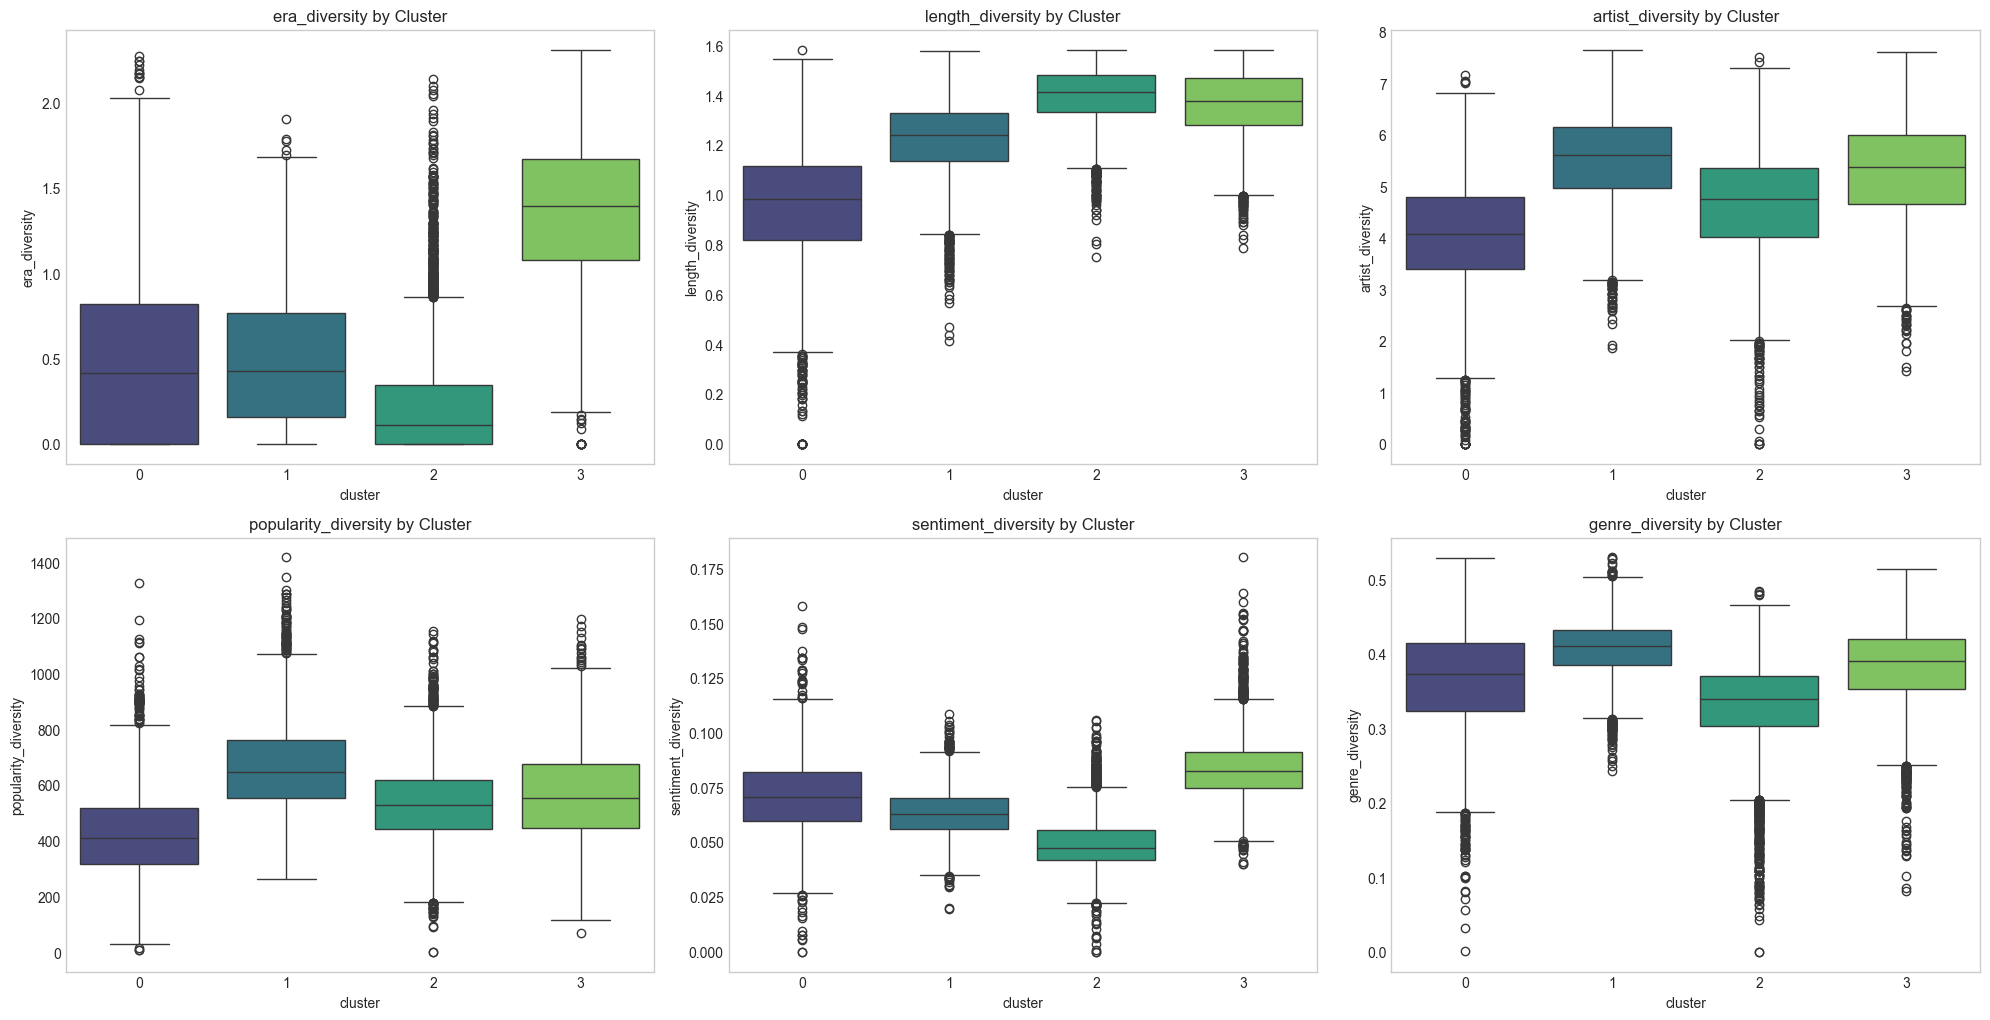

In [29]:
# Compare feature distributions across clusters with boxplots
plt.figure(figsize=(20, 15))
for i, feature in enumerate(feature_columns, 1):
    plt.subplot(3, 3, i)  # Adjust based on number of features
    sns.boxplot(x='cluster', y=feature, data=playlists_df, palette='viridis')
    plt.title(f'{feature} by Cluster')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [30]:
# There are 4 clusters (0 through 3)
cluster_names = {
    0: "Consistent Loyalists",
    1: "Trend-Saavy Seekers",
    2: "Focused Mood Crafters",
    3: "Universal Explorer",
}

print("\nCluster Names:")
for cluster, name in cluster_names.items():
    print(f"Cluster {cluster}: {name}")

# Map these names into the main dataframe
playlists_df['cluster_name'] = playlists_df['cluster'].map(cluster_names)

# Display sample playlists from each cluster
sample_size = 5  # Number of sample playlists per cluster
print("\nSample Playlists from Each Cluster:")
for cluster in playlists_df['cluster'].unique():
    cluster_samples = playlists_df[playlists_df['cluster'] == cluster].sample(
        min(sample_size, sum(playlists_df['cluster'] == cluster))
    )
    print(f"\nCluster {cluster} - {cluster_names.get(cluster, '')}")
    print(cluster_samples[['playlist_idx'] + feature_columns[:5]].to_string(index=False))

# Save the dataset with cluster assignments
playlists_df.to_csv('playlist_segmentation.csv', index=False)

# Export cluster information (if desired)
cluster_info = {
    'centers': cluster_centers.to_dict(),
    'profiles': cluster_profiles.to_dict(),
    'distinctive_features': distinctive_features.to_dict(),
    'names': cluster_names
}


Cluster Names:
Cluster 0: Consistent Loyalists
Cluster 1: Trend-Saavy Seekers
Cluster 2: Focused Mood Crafters
Cluster 3: Universal Explorer

Sample Playlists from Each Cluster:

Cluster 1 - Trend-Saavy Seekers
 playlist_idx  era_diversity  length_diversity  artist_diversity  popularity_diversity  sentiment_diversity
        13576       1.366377          1.190955          6.038662            676.345984             0.061310
         9298       0.090544          1.415821          5.003420            534.373134             0.060470
         4914       0.373951          1.221085          5.999246            669.247104             0.066666
        10739       0.000000          1.095795          5.286140            937.890032             0.086583
         8337       0.131107          1.227632          5.021824            607.319008             0.055014

Cluster 3 - Universal Explorer
 playlist_idx  era_diversity  length_diversity  artist_diversity  popularity_diversity  sentiment_diversity
